# 03 — Outliers

Companion to [`../../data_cleaning/outliers.md`](../../data_cleaning/outliers.md).

---

## What is an outlier?

An outlier is an observation that deviates markedly from the rest of the data. But not all outliers are errors:

- **Data entry error** (e.g., age = 200) → fix or drop
- **Genuine extreme value** (e.g., a billionaire in income data) → keep, but handle carefully
- **Rare event** (e.g., a fraud transaction) → often the most interesting signal

The key principle: **never drop outliers silently**. Always document why and how.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import IsolationForest

rng = np.random.default_rng(0)
n = 1000
income = rng.lognormal(10.5, 0.7, n)
# inject 1% extreme outliers
income[rng.choice(n, 10, replace=False)] *= 50
df = pd.DataFrame({'income': income})
df.describe()

,income
count,1.000000e+03
mean,6.847799e+04
std,2.643337e+05
min,2.369430e+03
25%,2.239732e+04
50%,3.473003e+04
75%,5.675153e+04
max,4.633480e+06


## 1. Visual inspection

Before applying any statistical rule, look at the data. Three views complement each other:

- **Linear histogram** — shows skew and extreme tails
- **Log-transformed histogram** — reveals the bulk distribution
- **ECDF (log x)** — shows the cumulative proportion, making tails visible

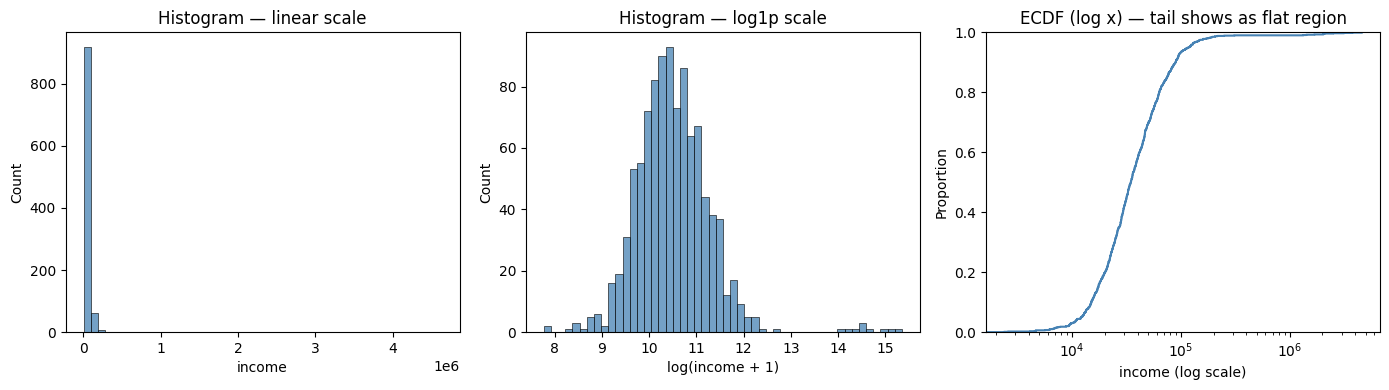

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df['income'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram — linear scale')
axes[0].set_xlabel('income')

sns.histplot(np.log1p(df['income']), bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Histogram — log1p scale')
axes[1].set_xlabel('log(income + 1)')

sns.ecdfplot(df['income'], ax=axes[2], color='steelblue')
axes[2].set_xscale('log')
axes[2].set_title('ECDF (log x) — tail shows as flat region')
axes[2].set_xlabel('income (log scale)')

plt.tight_layout(); plt.show()

### Box plot — the classic outlier view

The box plot uses the IQR rule (1.5 × IQR from Q1/Q3) to flag outliers as individual points.

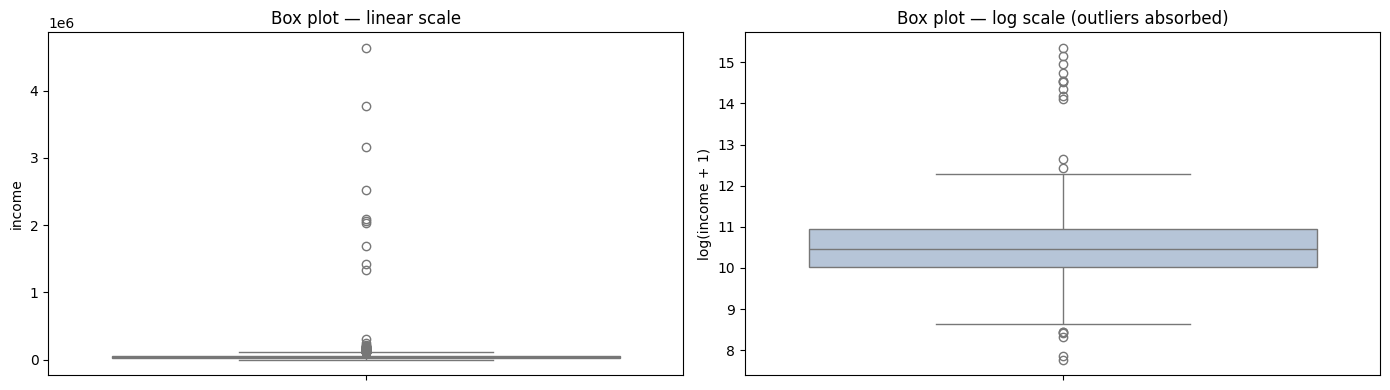

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(y=df['income'], ax=axes[0], color='lightsteelblue')
axes[0].set_ylabel('income'); axes[0].set_title('Box plot — linear scale')

sns.boxplot(y=np.log1p(df['income']), ax=axes[1], color='lightsteelblue')
axes[1].set_ylabel('log(income + 1)'); axes[1].set_title('Box plot — log scale (outliers absorbed)')
plt.tight_layout(); plt.show()

## 2. IQR rule (Tukey's fences)

The simplest statistical rule: any point outside `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` is an outlier. Works well for roughly symmetric distributions.

In [4]:
q1, q3 = df['income'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df['iqr_outlier'] = (df['income'] < lo) | (df['income'] > hi)
n_iqr = df['iqr_outlier'].sum()
print(f"IQR outliers: {n_iqr} / {len(df)} ({n_iqr/len(df)*100:.1f}%)")
print(f"Bounds: [{lo:,.0f}, {hi:,.0f}]")

IQR outliers: 58 / 1000 (5.8%)
Bounds: [-29,134, 108,283]


### Visualize IQR bounds on histogram

Red dashed lines show where the IQR fences fall.

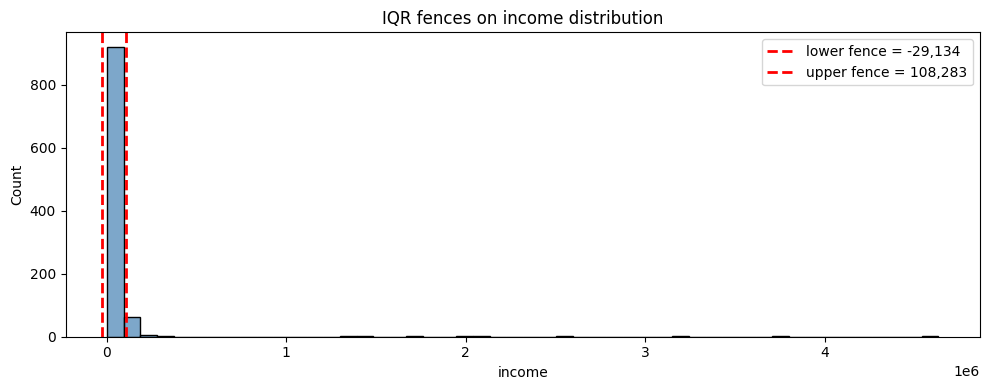

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['income'], bins=50, ax=ax, color='steelblue', alpha=0.7)
ax.axvline(lo, color='red', linestyle='--', linewidth=2, label=f'lower fence = {lo:,.0f}')
ax.axvline(hi, color='red', linestyle='--', linewidth=2, label=f'upper fence = {hi:,.0f}')
ax.set_xlabel('income'); ax.set_title('IQR fences on income distribution')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Modified z-score (robust)

Uses the median and MAD (median absolute deviation) instead of mean and std. More robust to the outliers themselves.

In [6]:
med = df['income'].median()
mad = (df['income'] - med).abs().median()
df['mz'] = 0.6745 * (df['income'] - med) / mad
df['mz_outlier'] = df['mz'].abs() > 3.5
n_mz = df['mz_outlier'].sum()
print(f"Modified z-score outliers: {n_mz} / {len(df)} ({n_mz/len(df)*100:.1f}%)")
print(f"Median: {med:,.0f}, MAD: {mad:,.0f}")

Modified z-score outliers: 54 / 1000 (5.4%)
Median: 34,730, MAD: 15,005


### Modified z-score distribution

Points beyond ±3.5 are flagged. The red dashed lines show the threshold.

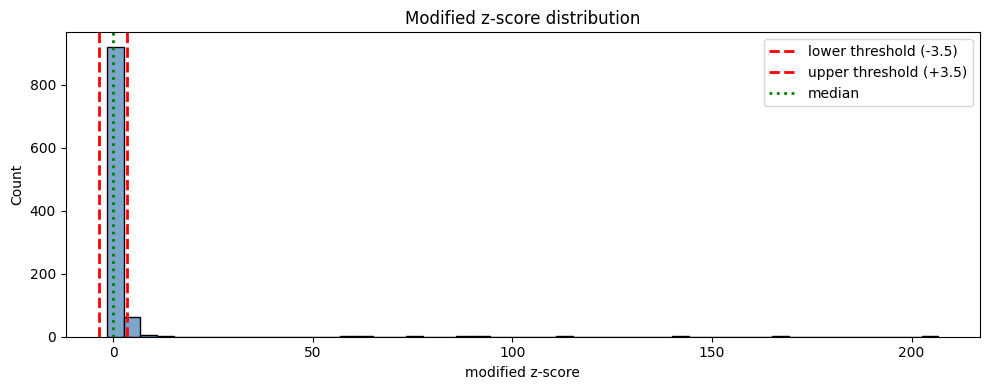

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['mz'], bins=50, ax=ax, color='steelblue', alpha=0.7)
ax.axvline(-3.5, color='red', linestyle='--', linewidth=2, label='lower threshold (-3.5)')
ax.axvline(3.5, color='red', linestyle='--', linewidth=2, label='upper threshold (+3.5)')
ax.axvline(0, color='green', linestyle=':', linewidth=2, label='median')
ax.set_xlabel('modified z-score'); ax.set_title('Modified z-score distribution')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Isolation Forest (multivariate-ready)

Isolation Forest isolates outliers by randomly splitting the data. Outliers require fewer splits, so they appear higher in the tree ensemble. Extends naturally to multiple dimensions.

In [8]:
iso = IsolationForest(contamination=0.01, random_state=0).fit(df[['income']])
df['iso_outlier'] = iso.predict(df[['income']]) == -1
n_iso = df['iso_outlier'].sum()
print(f"Isolation Forest outliers: {n_iso} / {len(df)} ({n_iso/len(df)*100:.1f}%)")

Isolation Forest outliers: 10 / 1000 (1.0%)


## 5. Comparison of methods

How many outliers does each method flag? Do they agree?

In [9]:
comparison = df[['iqr_outlier', 'mz_outlier', 'iso_outlier']].sum()
comparison.index = ['IQR', 'Modified z-score', 'Isolation Forest']
print(comparison)

IQR                 58
Modified z-score    54
Isolation Forest    10
dtype: int64


### Overlap heatmap

A heatmap shows which methods agree on which points. High overlap = confident outliers.

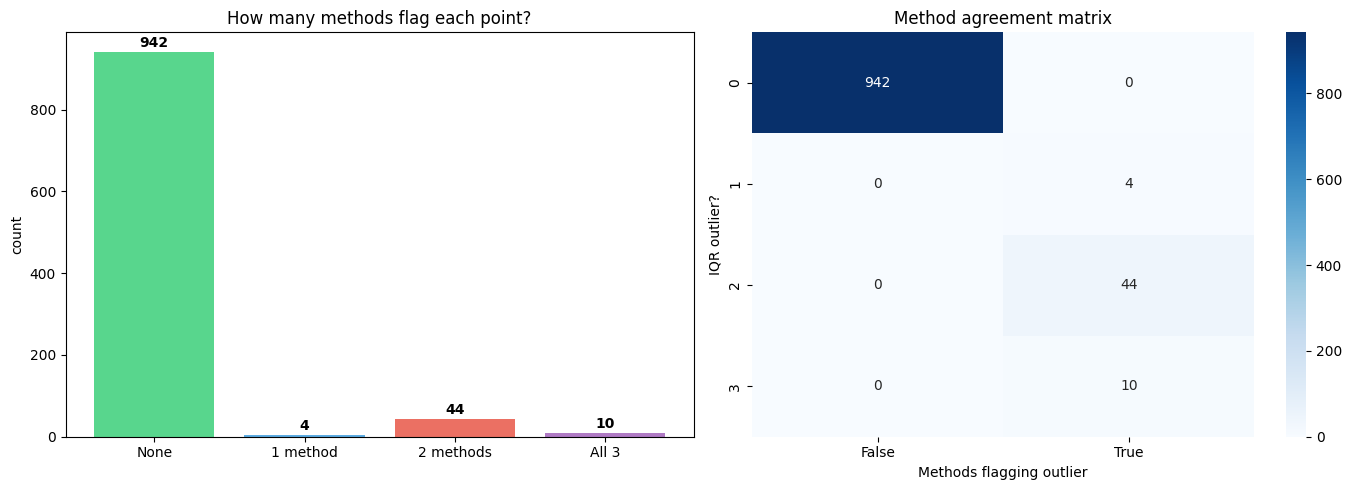

In [10]:
flags = df[['iqr_outlier', 'mz_outlier', 'iso_outlier']]
flags['total'] = flags.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of counts
counts = flags['total'].value_counts().sort_index()
labels = {0: 'None', 1: '1 method', 2: '2 methods', 3: 'All 3'}
x_pos = range(len(counts))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
bars = axes[0].bar(x_pos, [counts.get(i, 0) for i in x_pos], color=colors[:len(counts)], alpha=0.8)
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels([labels.get(i, str(i)) for i in x_pos])
axes[0].set_ylabel('count'); axes[0].set_title('How many methods flag each point?')
for bar, v in zip(bars, [counts.get(i, 0) for i in x_pos]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{int(v)}', ha='center', va='bottom', fontweight='bold')

# Agreement heatmap
agreement = pd.crosstab(flags['total'], flags['iqr_outlier'] + flags['mz_outlier'] + flags['iso_outlier'])
sns.heatmap(agreement, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_xlabel('Methods flagging outlier'); axes[1].set_ylabel('IQR outlier?')
axes[1].set_title('Method agreement matrix')

plt.tight_layout(); plt.show()

## 6. Response — what to do with outliers

Recall from the chapter: **never drop outliers silently**. Here are your options with demos.

### Option A: Log-transform (often makes outliers disappear)

For right-skewed data like income, a log transform compresses the tail.

Skewness (original):  12.09
Skewness (log1p):     1.27


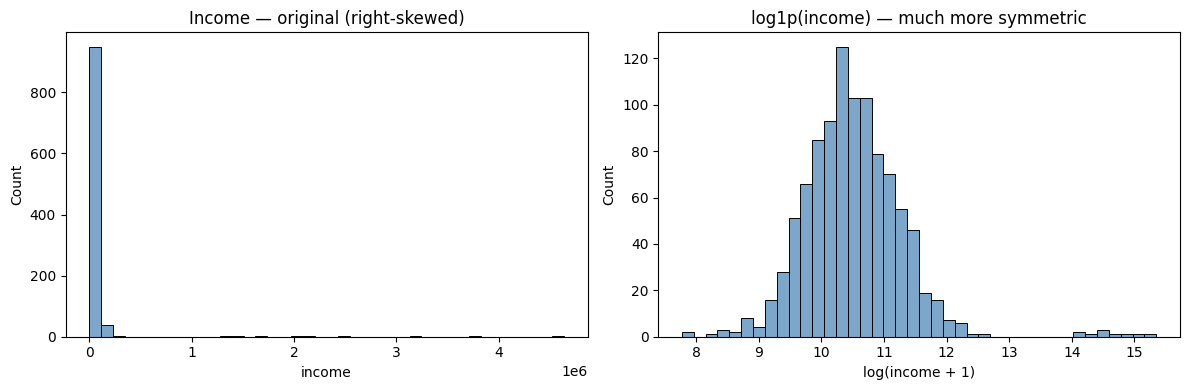

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['income'], bins=40, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Income — original (right-skewed)')
axes[0].set_xlabel('income')

sns.histplot(np.log1p(df['income']), bins=40, ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('log1p(income) — much more symmetric')
axes[1].set_xlabel('log(income + 1)')

print(f"Skewness (original):  {df['income'].skew():.2f}")
print(f"Skewness (log1p):     {np.log1p(df['income']).skew():.2f}")
plt.tight_layout(); plt.show()

### Option B: Winsorize (cap at percentiles)

Winsorization replaces extreme values with the value at a given percentile. It preserves the sample size while reducing tail influence.

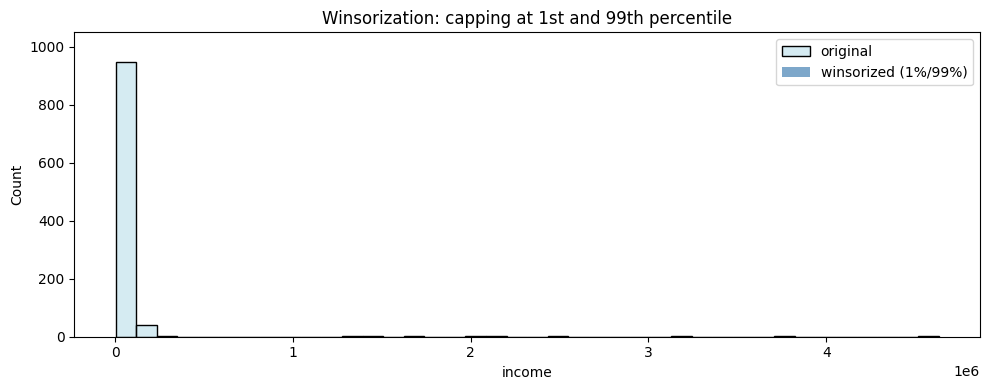

In [12]:
from scipy.stats import mstats

df['winsorized'] = mstats.winsorize(df['income'], limits=[0.01, 0.99])

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df['income'], bins=40, ax=ax, color='lightblue', alpha=0.5, label='original')
sns.histplot(df['winsorized'], bins=40, ax=ax, color='steelblue', alpha=0.7, label='winsorized (1%/99%)')
ax.axhline(0, color='white', linewidth=0)  # fix for dual hist
ax.set_xlabel('income'); ax.set_title('Winsorization: capping at 1st and 99th percentile')
ax.legend(); plt.tight_layout(); plt.show()

### Option C: Robust model (Huber regression)

Some models are inherently robust to outliers. Huber regression uses a loss function that is quadratic near the center but linear in the tails.

In [13]:
from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.model_selection import cross_val_score

rng2 = np.random.default_rng(42)
X = rng2.normal(0, 1, (500, 1)) * 100
y = 2.5 * X.ravel() + rng2.normal(0, 5, 500)
# inject outliers
out_idx = rng2.choice(500, 25, replace=False)
y[out_idx] *= 10

lr_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2').mean()
huber_scores = cross_val_score(HuberRegressor(), X, y, cv=5, scoring='r2').mean()

print(f"Linear Regression R²:  {lr_scores:.3f}")
print(f"Huber Regression R²:   {huber_scores:.3f}")
print(f"\n→ Huber is more robust to the injected outliers.")

Linear Regression R²:  0.449
Huber Regression R²:   0.446

→ Huber is more robust to the injected outliers.


### Option D: Drop with an audit log

If outliers are genuine data entry errors, drop them — but keep a record.

In [14]:
# Audit log: which rows were dropped and why
audit = df[df['iqr_outlier']].copy()
audit['drop_reason'] = 'IQR outlier'
print(f"Rows flagged for removal: {len(audit)}")
print("\nSample of flagged rows:")
audit.head()

Rows flagged for removal: 58

Sample of flagged rows:


,income,iqr_outlier,mz,mz_outlier,iso_outlier,winsorized,drop_reason
47,143226.249248,True,4.877002,True,False,6665.610922,IQR outlier
48,128174.053079,True,4.200392,True,False,6665.610922,IQR outlier
62,122707.347900,True,3.954659,True,False,6665.610922,IQR outlier
66,110021.492842,True,3.384418,False,False,6665.610922,IQR outlier
74,130015.370145,True,4.283161,True,False,6665.610922,IQR outlier


## Decision flowchart

When you encounter outliers, follow this decision process:

```
Is the outlier a data entry error?
  ├── Yes → Drop it. Log the row index and reason.
  └── No → Is the distribution heavily skewed?
            ├── Yes → Try log-transform. Re-check for outliers.
            └── No → Use robust methods:
                      - Winsorize (cap at percentiles)
                      - Huber regression / tree models
                      - Keep the outlier flag as a feature
```

**Golden rule**: Always document which points you flagged, why, and what you did with them.